# 3.3 Predicting Demographics from Imaging Features

This notebook reverses the analysis from 3.1 and 3.2 by treating **demographics as targets** instead of predictors.

## Research Questions:
1. **Can we predict Age from imaging features?** (Regression)
2. **Can we predict Sex from imaging features?** (Classification)
3. **How does demographic prediction compare to SBR pathology prediction?**

## Biological Interpretation:
- **High Age prediction accuracy** → Autoencoder learned age-related brain atrophy patterns
- **High Sex prediction accuracy** → Autoencoder learned sex-specific brain structure differences
- **Comparison with SBR prediction** → Shows whether pathology or demographics dominate the learned features

## Hypothesis:
If demographics were already encoded in imaging features (as suggested by their lack of added value in 3.1/3.2), we should be able to predict them with reasonable accuracy.

## Section 1: Setup and Data Preparation

### 1.1 Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge, LogisticRegression
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.decomposition import PCA

import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
pd.set_option('display.max_columns', None)

print("Libraries imported successfully!")

Libraries imported successfully!


### 1.2 Define Constants

In [2]:
# Image feature columns
FEATURE_COLS = [f'latent_{i}' for i in range(256)]

# SBR columns for PCA
SBR_COLS = [
    'DATSCAN_CAUDATE_R', 'DATSCAN_CAUDATE_L',
    'DATSCAN_PUTAMEN_R', 'DATSCAN_PUTAMEN_L',
    'DATSCAN_PUTAMEN_R_ANT', 'DATSCAN_PUTAMEN_L_ANT'
]

# Model parameters
ALPHA_RIDGE = 10.0
C_LOGISTIC = 1.0
N_SPLITS = 5
RANDOM_STATE = 42

print(f"Number of image features: {len(FEATURE_COLS)}")
print(f"Ridge alpha: {ALPHA_RIDGE}")
print(f"Logistic C: {C_LOGISTIC}")
print(f"CV folds: {N_SPLITS}")

Number of image features: 256
Ridge alpha: 10.0
Logistic C: 1.0
CV folds: 5


### 1.3 Load and Prepare Data

We'll use the test set (train latent vectors) since it has more samples (n=536)

In [3]:
# Load merged clinical/demographic data
# df_merged = pd.read_csv('output/merged_data.csv')
# print(f"Merged clinical data shape: {df_merged.shape}")

# # Load train set latent vectors
# latent_file = 'output/Experiments/LatentVectorAnalysis/train_latent_vectors_with_patno.csv'
# df_latent = pd.read_csv(latent_file)
# print(f"Train set latent vectors loaded: {df_latent.shape}")

# # Remove missing PATNOs and merge
# df_latent_clean = df_latent.dropna(subset=['PATNO']).copy()
# df_combined = pd.merge(df_latent_clean, df_merged, on='PATNO', how='inner')
# print(f"\nCombined dataset shape: {df_combined.shape}")

df_combined = pd.read_csv('output/final_train_combined_ae_data.csv')

print(f"Combined dataset shape: {df_combined.shape}")
print(f"Unique patients in combined data: {df_combined['PATNO'].nunique()}")

# Check for multiple visits per patient
visits_per_patient = df_combined.groupby('PATNO').size()
print(f"\nVisits per patient statistics:")
print(visits_per_patient.describe())
print(f"Patients with multiple visits: {(visits_per_patient > 1).sum()}")

# Calculate SBR PCs
df_with_sbr = df_combined.dropna(subset=SBR_COLS).copy()
scaler_sbr = StandardScaler()
sbr_scaled = scaler_sbr.fit_transform(df_with_sbr[SBR_COLS])
pca = PCA(n_components=3, random_state=0)
sbr_pcs = pca.fit_transform(sbr_scaled)
df_with_sbr['SBR_PC1'] = sbr_pcs[:, 0]
df_with_sbr['SBR_PC2'] = sbr_pcs[:, 1]
df_with_sbr['SBR_PC3'] = sbr_pcs[:, 2]
df_combined = df_with_sbr.copy()

# # Select best visit per patient
# def select_best_visit(group):
#     valid_rows = group.dropna(subset=['AGE_AT_VISIT', 'SEX', 'SBR_PC1', 'SBR_PC2', 'SBR_PC3'])
#     if len(valid_rows) == 0:
#         return None
#     if 'EVENT_ID' in valid_rows.columns:
#         priority = {'SC': 0, 'BL': 1, 'V01': 2, 'V02': 3}
#         valid_rows = valid_rows.copy()
#         valid_rows['priority'] = valid_rows['EVENT_ID'].map(priority).fillna(99)
#         return valid_rows.sort_values('priority').iloc[0:1]
#     return valid_rows.iloc[0:1]

# df_final = df_combined.groupby('PATNO', group_keys=False).apply(select_best_visit)
# df_final = df_final.dropna(subset=['PATNO']).reset_index(drop=True)

df_final = df_combined.dropna(subset=['PATNO']).reset_index(drop=True)

print(f"\nFinal dataset: {df_final.shape}")
print(f"Unique patients: {df_final['PATNO'].nunique()}")

Combined dataset shape: (2332, 304)
Unique patients in combined data: 1406

Visits per patient statistics:
count    1406.000000
mean        1.658606
std         0.951541
min         1.000000
25%         1.000000
50%         1.000000
75%         2.000000
max         4.000000
dtype: float64
Patients with multiple visits: 539

Final dataset: (2332, 307)
Unique patients: 1406


### 1.4 Extract Features and Targets

In [4]:
# Image features (X)
X_features = df_final[FEATURE_COLS].values
print(f"Image features shape: {X_features.shape}")

# Demographic targets
y_age = df_final['AGE_AT_VISIT'].values
y_sex = df_final['SEX'].values

print(f"\nAge statistics:")
print(f"  Mean: {y_age.mean():.2f}, Std: {y_age.std():.2f}")
print(f"  Range: [{y_age.min():.0f}, {y_age.max():.0f}]")

print(f"\nSex distribution:")
print(f"  Female (0): {(y_sex == 0).sum()} ({(y_sex == 0).sum()/len(y_sex)*100:.1f}%)")
print(f"  Male (1): {(y_sex == 1).sum()} ({(y_sex == 1).sum()/len(y_sex)*100:.1f}%)")

# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_features)
print(f"\nStandardized features: mean={X_scaled.mean():.6f}, std={X_scaled.std():.6f}")

Image features shape: (2332, 256)

Age statistics:
  Mean: nan, Std: nan
  Range: [nan, nan]

Sex distribution:
  Female (0): 880 (37.7%)
  Male (1): 1451 (62.2%)

Standardized features: mean=0.000000, std=1.000000


## Section 2: Age Prediction (Regression)

### 2.1 Train Age Prediction Model

In [5]:
print("=" * 80)
print("AGE PREDICTION FROM IMAGING FEATURES")
print("=" * 80)

# --- FIX: Remove samples with missing Age ---
# We create a mask for valid ages and apply it to both X and y
valid_mask = ~np.isnan(y_age)
X_age_clean = X_scaled[valid_mask]
y_age_clean = y_age[valid_mask]

print(f"Original samples: {len(y_age)}")
print(f"Samples with valid Age: {len(y_age_clean)}")
print(f"Dropped {len(y_age) - len(y_age_clean)} samples due to missing Age.")
print("-" * 80)

# Setup CV
kfold = KFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)

# Cross-validation (Using the CLEAN data)
cv_scores_r2 = cross_val_score(
    Ridge(alpha=ALPHA_RIDGE, random_state=RANDOM_STATE),
    X_age_clean, y_age_clean, cv=kfold, scoring='r2'
)

cv_scores_mae = -cross_val_score(
    Ridge(alpha=ALPHA_RIDGE, random_state=RANDOM_STATE),
    X_age_clean, y_age_clean, cv=kfold, scoring='neg_mean_absolute_error'
)

# Train-test split (Using the CLEAN data)
X_train, X_test, y_train, y_test = train_test_split(
    X_age_clean, y_age_clean, test_size=0.2, random_state=RANDOM_STATE
)

# Train model
model_age = Ridge(alpha=ALPHA_RIDGE, random_state=RANDOM_STATE)
model_age.fit(X_train, y_train)

# Predictions
y_pred_train = model_age.predict(X_train)
y_pred_test = model_age.predict(X_test)

# Evaluate
r2_train = r2_score(y_train, y_pred_train)
r2_test = r2_score(y_test, y_pred_test)
mae_train = mean_absolute_error(y_train, y_pred_train)
mae_test = mean_absolute_error(y_test, y_pred_test)
rmse_test = np.sqrt(mean_squared_error(y_test, y_pred_test))

print(f"\nTrain Set Performance:")
print(f"  R² Score: {r2_train:.4f}")
print(f"  MAE: {mae_train:.2f} years")

print(f"\nTest Set Performance:")
print(f"  R² Score: {r2_test:.4f}")
print(f"  MAE: {mae_test:.2f} years")
print(f"  RMSE: {rmse_test:.2f} years")

print(f"\nCross-Validation Performance:")
print(f"  R² Score: {cv_scores_r2.mean():.4f} (±{cv_scores_r2.std():.4f})")
print(f"  MAE: {cv_scores_mae.mean():.2f} (±{cv_scores_mae.std():.2f}) years")

# Store results
age_results = {
    'r2_train': r2_train,
    'r2_test': r2_test,
    'r2_cv_mean': cv_scores_r2.mean(),
    'r2_cv_std': cv_scores_r2.std(),
    'mae_train': mae_train,
    'mae_test': mae_test,
    'mae_cv_mean': cv_scores_mae.mean(),
    'mae_cv_std': cv_scores_mae.std(),
    'rmse_test': rmse_test
}

AGE PREDICTION FROM IMAGING FEATURES
Original samples: 2332
Samples with valid Age: 2331
Dropped 1 samples due to missing Age.
--------------------------------------------------------------------------------

Train Set Performance:
  R² Score: 0.6035
  MAE: 4.99 years

Test Set Performance:
  R² Score: 0.4614
  MAE: 5.62 years
  RMSE: 7.12 years

Cross-Validation Performance:
  R² Score: 0.4545 (±0.0204)
  MAE: 5.80 (±0.21) years


### 2.2 Visualize Age Predictions

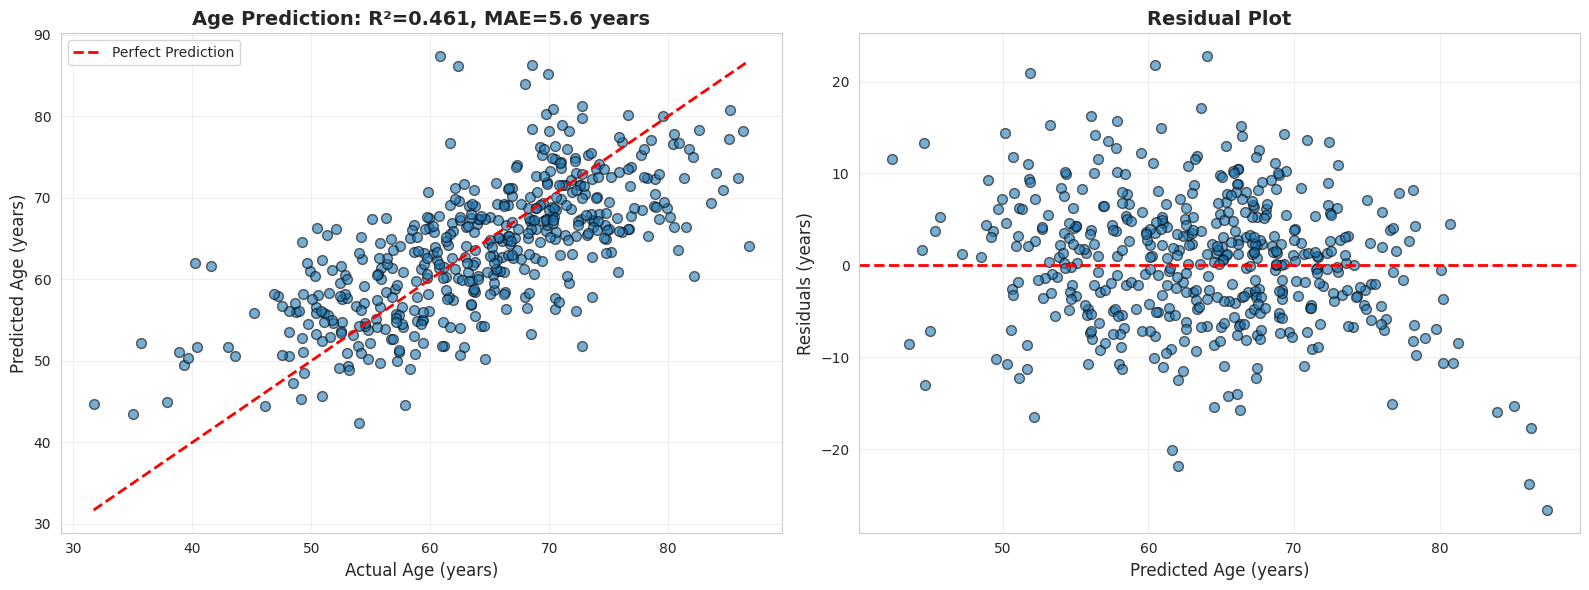

Plot saved to: output/age_prediction_from_imaging.png


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Predicted vs Actual Age
axes[0].scatter(y_test, y_pred_test, alpha=0.6, edgecolor='black', s=50)
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 
             'r--', lw=2, label='Perfect Prediction')
axes[0].set_xlabel('Actual Age (years)', fontsize=12)
axes[0].set_ylabel('Predicted Age (years)', fontsize=12)
axes[0].set_title(f'Age Prediction: R²={r2_test:.3f}, MAE={mae_test:.1f} years', 
                  fontsize=14, fontweight='bold')
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

# Plot 2: Residuals
residuals = y_test - y_pred_test
axes[1].scatter(y_pred_test, residuals, alpha=0.6, edgecolor='black', s=50)
axes[1].axhline(y=0, color='r', linestyle='--', lw=2)
axes[1].set_xlabel('Predicted Age (years)', fontsize=12)
axes[1].set_ylabel('Residuals (years)', fontsize=12)
axes[1].set_title('Residual Plot', fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('output/age_prediction_from_imaging.png', dpi=150, bbox_inches='tight')
plt.show()

print("Plot saved to: output/age_prediction_from_imaging.png")

## Section 3: Sex Prediction (Classification)

### 3.1 Train Sex Prediction Model

In [7]:
print("\n" + "=" * 80)
print("SEX PREDICTION FROM IMAGING FEATURES")
print("=" * 80)

# --- FIX: Remove samples with missing Sex labels ---
# Create a mask for valid sex labels (0 or 1)
valid_mask = ~np.isnan(y_sex)
X_sex_clean = X_scaled[valid_mask]
y_sex_clean = y_sex[valid_mask]

print(f"Original samples: {len(y_sex)}")
print(f"Samples with valid Sex label: {len(y_sex_clean)}")
print(f"Dropped {len(y_sex) - len(y_sex_clean)} samples due to missing Sex.")
print("-" * 80)

# Cross-validation (Use cleaned data)
cv_scores_acc = cross_val_score(
    LogisticRegression(C=C_LOGISTIC, random_state=RANDOM_STATE, max_iter=1000),
    X_sex_clean, y_sex_clean, cv=kfold, scoring='accuracy'
)

cv_scores_roc = cross_val_score(
    LogisticRegression(C=C_LOGISTIC, random_state=RANDOM_STATE, max_iter=1000),
    X_sex_clean, y_sex_clean, cv=kfold, scoring='roc_auc'
)

# Train-test split (Use cleaned data)
X_train, X_test, y_train, y_test = train_test_split(
    X_sex_clean, y_sex_clean, test_size=0.2, random_state=RANDOM_STATE, stratify=y_sex_clean
)

# Train model
model_sex = LogisticRegression(C=C_LOGISTIC, random_state=RANDOM_STATE, max_iter=1000)
model_sex.fit(X_train, y_train)

# Predictions
y_pred_train = model_sex.predict(X_train)
y_pred_test = model_sex.predict(X_test)
y_pred_proba_test = model_sex.predict_proba(X_test)[:, 1]

# Evaluate
acc_train = accuracy_score(y_train, y_pred_train)
acc_test = accuracy_score(y_test, y_pred_test)
precision_test = precision_score(y_test, y_pred_test)
recall_test = recall_score(y_test, y_pred_test)
f1_test = f1_score(y_test, y_pred_test)
roc_auc_test = roc_auc_score(y_test, y_pred_proba_test)

print(f"\nTrain Set Performance:")
print(f"  Accuracy: {acc_train:.4f}")

print(f"\nTest Set Performance:")
print(f"  Accuracy: {acc_test:.4f}")
print(f"  Precision: {precision_test:.4f}")
print(f"  Recall: {recall_test:.4f}")
print(f"  F1-Score: {f1_test:.4f}")
print(f"  ROC-AUC: {roc_auc_test:.4f}")

print(f"\nCross-Validation Performance:")
print(f"  Accuracy: {cv_scores_acc.mean():.4f} (±{cv_scores_acc.std():.4f})")
print(f"  ROC-AUC: {cv_scores_roc.mean():.4f} (±{cv_scores_roc.std():.4f})")

# Baseline (majority class)
baseline_acc = max((y_sex_clean == 0).sum(), (y_sex_clean == 1).sum()) / len(y_sex_clean)
print(f"\nBaseline (majority class): {baseline_acc:.4f}")
print(f"Improvement over baseline: {(acc_test - baseline_acc):.4f}")

# Store results
sex_results = {
    'acc_train': acc_train,
    'acc_test': acc_test,
    'acc_cv_mean': cv_scores_acc.mean(),
    'acc_cv_std': cv_scores_acc.std(),
    'precision': precision_test,
    'recall': recall_test,
    'f1': f1_test,
    'roc_auc_test': roc_auc_test,
    'roc_auc_cv_mean': cv_scores_roc.mean(),
    'roc_auc_cv_std': cv_scores_roc.std(),
    'baseline': baseline_acc
}


SEX PREDICTION FROM IMAGING FEATURES
Original samples: 2332
Samples with valid Sex label: 2331
Dropped 1 samples due to missing Sex.
--------------------------------------------------------------------------------

Train Set Performance:
  Accuracy: 0.8922

Test Set Performance:
  Accuracy: 0.7880
  Precision: 0.8429
  Recall: 0.8110
  F1-Score: 0.8266
  ROC-AUC: 0.8575

Cross-Validation Performance:
  Accuracy: 0.8035 (±0.0130)
  ROC-AUC: 0.8771 (±0.0148)

Baseline (majority class): 0.6225
Improvement over baseline: 0.1655


### 3.2 Visualize Sex Predictions

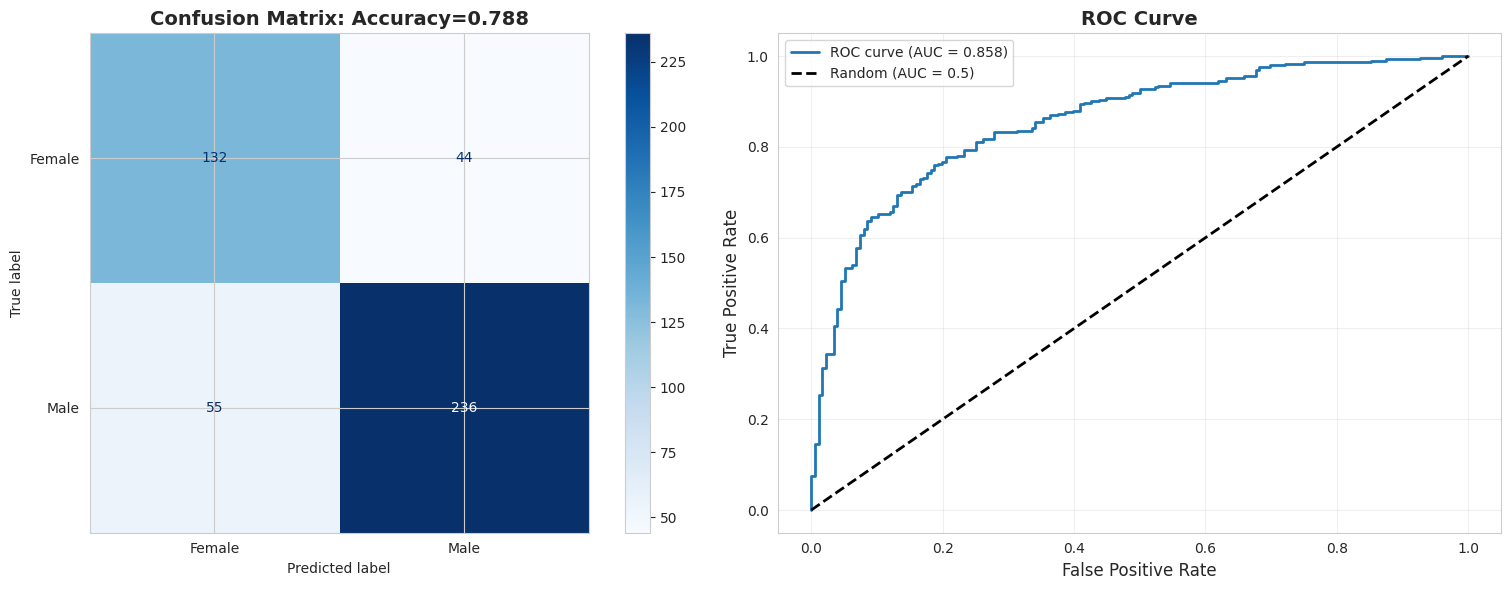

Plot saved to: output/sex_prediction_from_imaging.png


In [8]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_curve

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Confusion Matrix
cm = confusion_matrix(y_test, y_pred_test)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Female', 'Male'])
disp.plot(ax=axes[0], cmap='Blues', values_format='d')
axes[0].set_title(f'Confusion Matrix: Accuracy={acc_test:.3f}', fontsize=14, fontweight='bold')

# Plot 2: ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_pred_proba_test)
axes[1].plot(fpr, tpr, lw=2, label=f'ROC curve (AUC = {roc_auc_test:.3f})')
axes[1].plot([0, 1], [0, 1], 'k--', lw=2, label='Random (AUC = 0.5)')
axes[1].set_xlabel('False Positive Rate', fontsize=12)
axes[1].set_ylabel('True Positive Rate', fontsize=12)
axes[1].set_title('ROC Curve', fontsize=14, fontweight='bold')
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('output/sex_prediction_from_imaging.png', dpi=150, bbox_inches='tight')
plt.show()

print("Plot saved to: output/sex_prediction_from_imaging.png")

## Section 4: Comparison with SBR Prediction

### 4.1 Load SBR Prediction Results

In [9]:
# Load test set SBR results
sbr_results_path = 'output/test_set_results.csv'

if Path(sbr_results_path).exists():
    df_sbr_results = pd.read_csv(sbr_results_path)
    
    # Extract Image Features Only results
    sbr_img_only = df_sbr_results[df_sbr_results['Model'] == 'Image Features Only']
    
    print("SBR Prediction Performance (Image Features Only):")
    print("\nCV R² Scores:")
    for _, row in sbr_img_only.iterrows():
        print(f"  {row['Target']}: {row['R2_Score_CV_Mean']:.4f} (±{row['R2_Score_CV_Std']:.4f})")
else:
    print(f"⚠️ SBR results not found at {sbr_results_path}")
    print("Run notebook 3.2 first.")
    df_sbr_results = None

SBR Prediction Performance (Image Features Only):

CV R² Scores:
  SBR_PC1: 0.9761 (±0.0031)
  SBR_PC2: 0.8650 (±0.0131)
  SBR_PC3: 0.8025 (±0.0192)


### 4.2 Create Comparison Summary

In [10]:
print("\n" + "=" * 80)
print("COMPARISON: DEMOGRAPHICS vs SBR PATHOLOGY PREDICTION")
print("=" * 80)

comparison_data = [
    {
        'Target': 'Age',
        'Type': 'Demographic',
        'Metric': 'R² (CV)',
        'Score': age_results['r2_cv_mean'],
        'Std': age_results['r2_cv_std']
    },
    {
        'Target': 'Sex',
        'Type': 'Demographic',
        'Metric': 'ROC-AUC (CV)',
        'Score': sex_results['roc_auc_cv_mean'],
        'Std': sex_results['roc_auc_cv_std']
    }
]

if df_sbr_results is not None:
    for _, row in sbr_img_only.iterrows():
        comparison_data.append({
            'Target': row['Target'],
            'Type': 'SBR Pathology',
            'Metric': 'R² (CV)',
            'Score': row['R2_Score_CV_Mean'],
            'Std': row['R2_Score_CV_Std']
        })

df_comparison = pd.DataFrame(comparison_data)
print("\n", df_comparison.to_string(index=False))

print("\n" + "=" * 80)
print("KEY INSIGHTS")
print("=" * 80)
print(f"\n1. Age Prediction: R²={age_results['r2_cv_mean']:.3f}")
print(f"   → MAE = {age_results['mae_cv_mean']:.1f} years")
print(f"   → Imaging features {'CAN' if age_results['r2_cv_mean'] > 0.3 else 'CANNOT'} predict age")

print(f"\n2. Sex Prediction: Accuracy={sex_results['acc_cv_mean']:.3f}, ROC-AUC={sex_results['roc_auc_cv_mean']:.3f}")
print(f"   → Improvement over baseline: {(sex_results['acc_cv_mean'] - sex_results['baseline']):.3f}")
print(f"   → Imaging features {'CAN' if sex_results['roc_auc_cv_mean'] > 0.6 else 'CANNOT'} distinguish sex")

if df_sbr_results is not None:
    sbr_pc1_r2 = sbr_img_only[sbr_img_only['Target']=='SBR_PC1']['R2_Score_CV_Mean'].values[0]
    print(f"\n3. SBR_PC1 Prediction: R²={sbr_pc1_r2:.3f}")
    print(f"   → Pathology prediction is {'MUCH STRONGER' if sbr_pc1_r2 > age_results['r2_cv_mean'] + 0.2 else 'STRONGER'} than age prediction")
    print(f"   → Ratio: {sbr_pc1_r2 / age_results['r2_cv_mean']:.1f}× better")


COMPARISON: DEMOGRAPHICS vs SBR PATHOLOGY PREDICTION

  Target          Type       Metric    Score      Std
    Age   Demographic      R² (CV) 0.454522 0.020366
    Sex   Demographic ROC-AUC (CV) 0.877139 0.014794
SBR_PC1 SBR Pathology      R² (CV) 0.976087 0.003121
SBR_PC2 SBR Pathology      R² (CV) 0.864974 0.013058
SBR_PC3 SBR Pathology      R² (CV) 0.802454 0.019226

KEY INSIGHTS

1. Age Prediction: R²=0.455
   → MAE = 5.8 years
   → Imaging features CAN predict age

2. Sex Prediction: Accuracy=0.804, ROC-AUC=0.877
   → Improvement over baseline: 0.181
   → Imaging features CAN distinguish sex

3. SBR_PC1 Prediction: R²=0.976
   → Pathology prediction is MUCH STRONGER than age prediction
   → Ratio: 2.1× better


### 4.3 Visualization: Demographics vs SBR Comparison

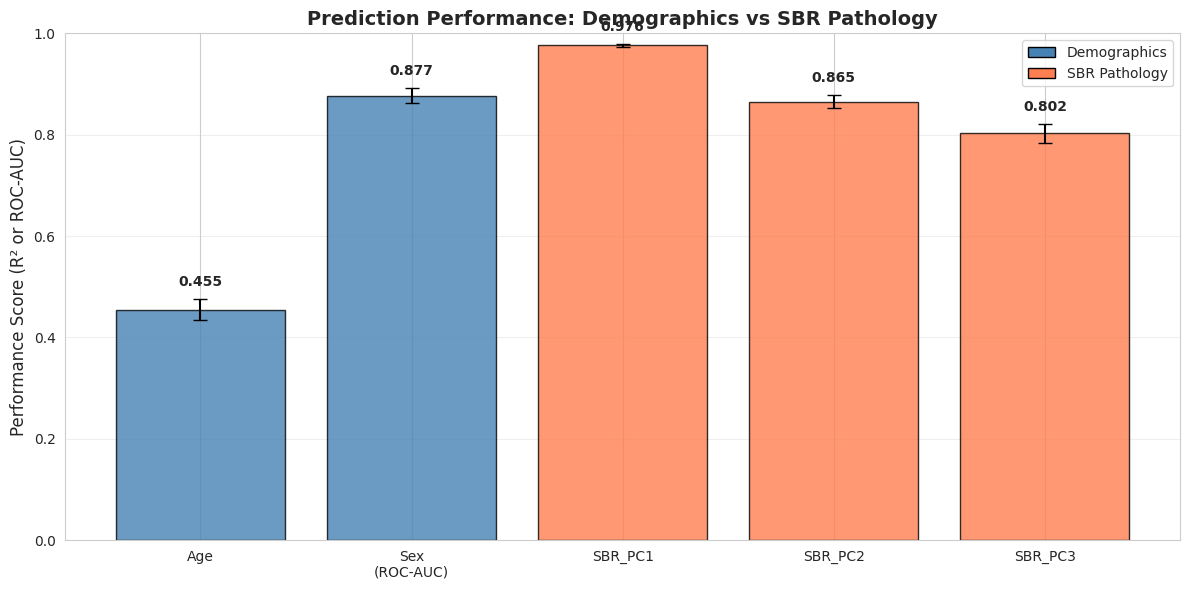


Plot saved to: output/demographics_vs_sbr_comparison.png


In [11]:
if df_sbr_results is not None:
    fig, ax = plt.subplots(1, 1, figsize=(12, 6))
    
    # Prepare data
    targets = ['Age', 'Sex\n(ROC-AUC)', 'SBR_PC1', 'SBR_PC2', 'SBR_PC3']
    scores = [
        age_results['r2_cv_mean'],
        sex_results['roc_auc_cv_mean'],
        sbr_img_only[sbr_img_only['Target']=='SBR_PC1']['R2_Score_CV_Mean'].values[0],
        sbr_img_only[sbr_img_only['Target']=='SBR_PC2']['R2_Score_CV_Mean'].values[0],
        sbr_img_only[sbr_img_only['Target']=='SBR_PC3']['R2_Score_CV_Mean'].values[0]
    ]
    stds = [
        age_results['r2_cv_std'],
        sex_results['roc_auc_cv_std'],
        sbr_img_only[sbr_img_only['Target']=='SBR_PC1']['R2_Score_CV_Std'].values[0],
        sbr_img_only[sbr_img_only['Target']=='SBR_PC2']['R2_Score_CV_Std'].values[0],
        sbr_img_only[sbr_img_only['Target']=='SBR_PC3']['R2_Score_CV_Std'].values[0]
    ]
    colors = ['steelblue', 'steelblue', 'coral', 'coral', 'coral']
    
    # Bar plot
    bars = ax.bar(targets, scores, yerr=stds, capsize=5, color=colors, alpha=0.8, edgecolor='black')
    
    # Add value labels
    for i, (target, score) in enumerate(zip(targets, scores)):
        ax.text(i, score + stds[i] + 0.02, f'{score:.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
    
    ax.set_ylabel('Performance Score (R² or ROC-AUC)', fontsize=12)
    ax.set_title('Prediction Performance: Demographics vs SBR Pathology', fontsize=14, fontweight='bold')
    ax.set_ylim([0, 1.0])
    ax.grid(True, alpha=0.3, axis='y')
    
    # Add legend
    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor='steelblue', edgecolor='black', label='Demographics'),
        Patch(facecolor='coral', edgecolor='black', label='SBR Pathology')
    ]
    ax.legend(handles=legend_elements, fontsize=10)
    
    plt.tight_layout()
    plt.savefig('output/demographics_vs_sbr_comparison.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    print("\nPlot saved to: output/demographics_vs_sbr_comparison.png")

### 4.4 Save Results

In [12]:
# Save demographic prediction results
output_dir = Path('output')

# Age results
pd.DataFrame([age_results]).to_csv(output_dir / 'age_prediction_results.csv', index=False)

# Sex results
pd.DataFrame([sex_results]).to_csv(output_dir / 'sex_prediction_results.csv', index=False)

# Comparison
df_comparison.to_csv(output_dir / 'demographics_vs_sbr_comparison.csv', index=False)

print("Results saved to:")
print(f"  - {output_dir / 'age_prediction_results.csv'}")
print(f"  - {output_dir / 'sex_prediction_results.csv'}")
print(f"  - {output_dir / 'demographics_vs_sbr_comparison.csv'}")

Results saved to:
  - output/age_prediction_results.csv
  - output/sex_prediction_results.csv
  - output/demographics_vs_sbr_comparison.csv
